In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set(style="whitegrid")

RAW_PATH = "../data/raw/dataset.csv"
PROCESSED_PATH = "../data/processed/dataset.json"

In [2]:
df = pd.read_csv(RAW_PATH)

print("Shape:", df.shape)
df.head()

Shape: (301, 4)


,categorie,zarma,haoussa,francais
0,salutations,Fofo,Sannu,Bonjour
1,salutations,Fonda kayan,Sannu da zuwa,Bienvenue
2,salutations,Mateno nigo?,Yaya kake?,Comment vas-tu ? (A un homme)
3,salutations,Mateno nigo?,Yaya kike?,Comment vas-tu ? (A une femme)
4,salutations,Banisamey wallah,Lafiya lawe,Je vais bien


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   categorie  301 non-null    object
 1   zarma      300 non-null    object
 2   haoussa    301 non-null    object
 3   francais   300 non-null    object
dtypes: object(4)
memory usage: 9.5+ KB


In [4]:
df.isnull().sum()

categorie    0
zarma        1
haoussa      0
francais     1
dtype: int64

In [5]:
df["haoussa"] = df["haoussa"].astype(str).str.strip().str.lower()
df["zarma"] = df["zarma"].astype(str).str.strip().str.lower()

In [6]:
df["hausa_len"] = df["haoussa"].apply(lambda x: len(str(x).split()))
df["zarma_len"] = df["zarma"].apply(lambda x: len(str(x).split()))

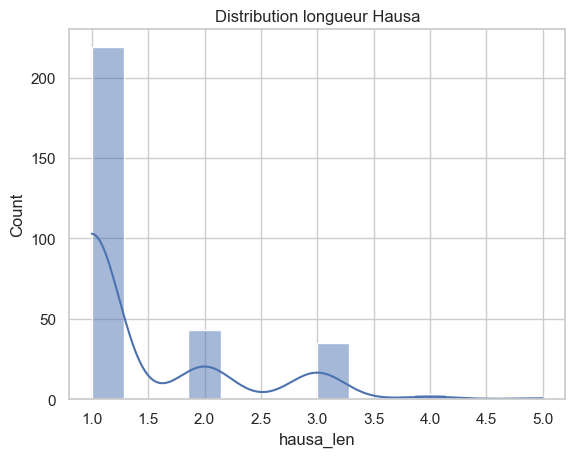

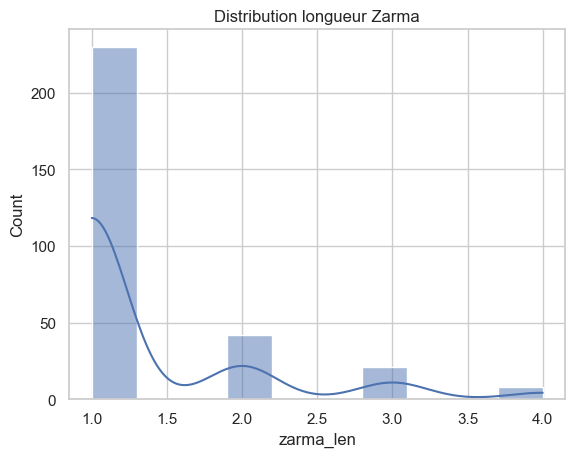

In [7]:
plt.figure()
sns.histplot(df["hausa_len"], kde=True)
plt.title("Distribution longueur Hausa")
plt.show()

plt.figure()
sns.histplot(df["zarma_len"], kde=True)
plt.title("Distribution longueur Zarma")
plt.show()

In [8]:
duplicates = df.duplicated(subset=["haoussa", "zarma"]).sum()
print("Doublons:", duplicates)

Doublons: 2


In [9]:
duplicates = df.duplicated(subset=["haoussa", "zarma"]).sum()
print("Doublons:", duplicates)

Doublons: 2


In [10]:
def count_variants(text):
    if isinstance(text, str):
        return len(text.split("/"))
    return 0

df["hausa_variants"] = df["haoussa"].apply(count_variants)
df["zarma_variants"] = df["zarma"].apply(count_variants)

df[["hausa_variants", "zarma_variants"]].describe()

,hausa_variants,zarma_variants
count,301.000000,301.000000
mean,1.039867,1.003322
std,0.195973,0.057639
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,2.000000,2.000000


In [11]:
def get_vocab(texts):
    vocab = []
    for t in texts:
        vocab.extend(str(t).split())
    return Counter(vocab)

hausa_vocab = get_vocab(df["haoussa"])
zarma_vocab = get_vocab(df["zarma"])

print("Vocab Hausa:", len(hausa_vocab))
print("Vocab Zarma:", len(zarma_vocab))

Vocab Hausa: 298
Vocab Zarma: 309


In [12]:
print("Top Hausa:", hausa_vocab.most_common(10))
print("Top Zarma:", zarma_vocab.most_common(10))

Top Hausa: [('ina', 13), ('sha', 11), ('da', 10), ('goma', 10), ('lafiya', 5), ('ciki', 5), ('ciwo', 5), ('sannu', 4), ('na', 4), ('/', 4)]
Top Zarma: [('ay', 21), ('iway', 10), ('tchindi', 9), ('go', 7), ('no', 4), ('mateno', 3), ('koy', 3), ('loktora', 3), ('goumo', 3), ('nigo?', 2)]


In [13]:
with open(PROCESSED_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Dataset size:", len(data))
data[:5]

Dataset size: 1329


[{'translation': {'hausa': 'dalibai', 'zarma': 'lacolize'}},
 {'translation': {'hausa': 'duka !', 'zarma': 'kulu'}},
 {'translation': {'hausa': 'sai gobe ?', 'zarma': 'kalsoubah'}},
 {'translation': {'hausa': 'ina kasuwa ?', 'zarma': 'mano habu?'}},
 {'translation': {'hausa': 'kakata (mace) !', 'zarma': 'ay kayi'}}]

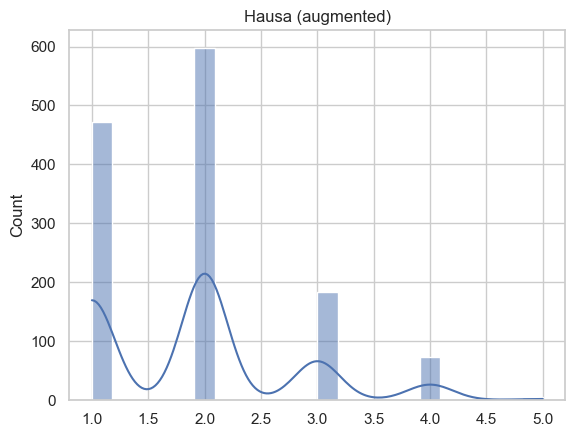

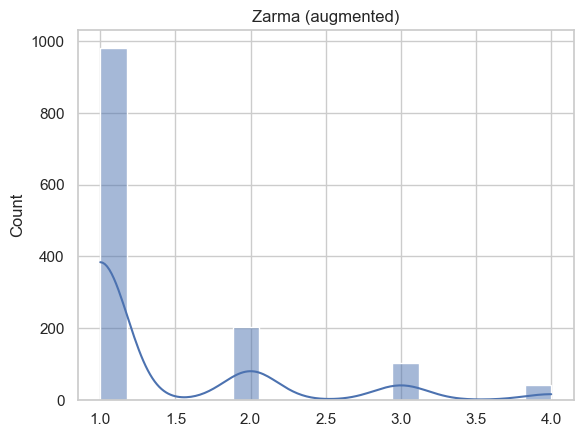

In [14]:
hausa_lens = [len(d["translation"]["hausa"].split()) for d in data]
zarma_lens = [len(d["translation"]["zarma"].split()) for d in data]

plt.figure()
sns.histplot(hausa_lens, kde=True)
plt.title("Hausa (augmented)")
plt.show()

plt.figure()
sns.histplot(zarma_lens, kde=True)
plt.title("Zarma (augmented)")
plt.show()

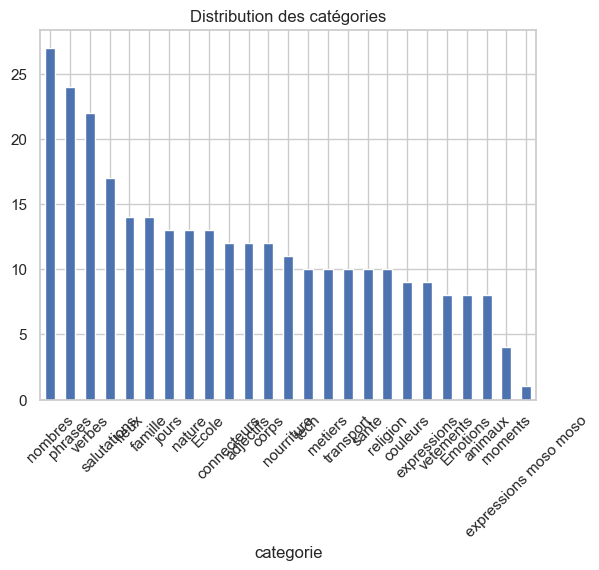

In [15]:
categories = df["categorie"].value_counts()

plt.figure()
categories.plot(kind="bar")
plt.title("Distribution des catégories")
plt.xticks(rotation=45)
plt.show()